# Lab 2: Geostrophic Adjustment

**Driving question:** How does geostrophic balance get established from some initial disturbance, and what governs the nature of this *geostrophic adjustment*?

**Your task:** This notebook already contains a complete model that simulates geostrophic adjustment and horizontal propagating shallow water waves by numerically solving (i.e., integrating) the linearized shallow water equations. Your job is to:
1. Use this model to run experiments by modifying key parameters
2. Create visuals that help you demonstrate the sensitivities of geostrophic adjustment to those changes
3. Write up interpretations in markdown boxes at the bottom of this notebook.

More below on each of these tasks...

**Due date:** complete this notebook and push it to your repo by 11:59 PM, Friday Sept. 18th.

## Model overview

This model numerically solves the shallow water equations of motion for a one-dimensional disturbance on an $f$-plane. Wave propagation and divergent motion manifest in the $x$-dimension. The $v$-wind oscillates through Coriolis deflection, but with no divergence. In this sense, there is no propagation in $y$. The model is linearized: we will neglect nonlinear advection, which significantly simplifies solutions. The equations that the model solves are as follows:

$$
\frac{\partial u}{\partial t}-f_0v=-g\frac{\partial h}{\partial x},
$$

$$
\frac{\partial v}{\partial t}+f_0u=0,
$$

$$
\frac{\partial h}{\partial t}+H\frac{\partial u}{\partial x}=0.
$$

As in class, $u$ and $v$ are the perturbation velocity components, $h$ is the perturbation layer height, $H$ is the base state layer depth, $f_0$ is the Coriolis parameter, and $g$ is gravity.

To kick off disturbances, the model is initialized with an initial Gaussian height anomaly and resting initial-state velocity:

$$
h(0,x)=h_0\exp\left[-\frac{x^2}{2L_0^2}\right],
\quad u(0,x)=v(0,x)=0.
$$

This initial height perturbation requires two input parameters:
1. $L_0$ assumed horizontal length scale (i.e., Gaussian width)
2. $h_0$ amplitude

## Model parameters that can remain unmodified

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import metpy 



# Note: most settings below are just the default values.
# Many can be overridden when the model is called further down the notebook.

# Physical constants
G = 9.81                         # m s^-2
OMEGA = 7.2921159e-5             # Earth's rotation rate, s^-1
H = 250.0                        # base state layer depth, m

# Spatial grid
DOMAIN_LENGTH = 20_000_000.0     # 20,000 km
NX = 1000                        # Number of grid points
DX = DOMAIN_LENGTH / NX          # Grid spacing, m
X = (np.arange(NX) - NX // 2) * DX # X-grid, m

# Initial Gaussian disturbance
L_0 = 600_000.0                  # Length scale, i.e., Gaussian width, m
h_0 = 10.0                       # Initial disturbance amplitude, m

# Time integration
DT = 120.0                       # Time step, s
STOP_TIME = 200.0 * 3600.0        # Experiment duration, s #FIXME Hours changed
SAVE_EVERY = 5                   # Save output every x time steps

# Print some basic information about the simulation
print(f"Grid spacing: {DX / 1000:.1f} km")
print(f"Grid size: {NX * DX / 1000:.0f} km")
print(f"Experiment duration: {STOP_TIME / 3600:.0f} h")
print(f"Time step: {DT / 60:.1f} min")
print()

# Print some default settings
print(f"Initial disturbance width L_0: {L_0 / 1000:.0f} km")
print(f"Initial disturbance amplitude h_0: {h_0} m")

Grid spacing: 20.0 km
Grid size: 20000 km
Experiment duration: 200 h
Time step: 2.0 min

Initial disturbance width L_0: 600 km
Initial disturbance amplitude h_0: 10.0 m


## Model engine

### Support functions

In [20]:
# Calculate the Coriolis parameter f_0
def coriolis_parameter(latitude_degrees):
    latitude_radians = np.deg2rad(latitude_degrees)
    return 2.0 * OMEGA * np.sin(latitude_radians)

# Calculate the x-gradient using a second-order centered difference scheme
# with periodic boundary conditions
def centered_gradient(field, dx=DX):
    return (np.roll(field, -1, axis=-1) - np.roll(field, 1, axis=-1)) / (2.0 * dx)

# Initially resting fluid with a centered Gaussian height anomaly
def initial_conditions(amplitude=h_0, width=L_0, x=X):
    h = amplitude * np.exp(-0.5 * (x / width) ** 2)
    u = np.zeros_like(h)
    v = np.zeros_like(h)
    return u, v, h

### Main driver functions

In [21]:
# Advance the fields to the next time step with a centered half/full/half-step update
def advance_one_step(u0, v0, h0, dt, f_0, g=G, mean_depth=H, dx=DX):

    # This is where our equations of motion are implemented
    # 
    # The centered half/full/half-step update is a numerical integration scheme that
    # updates the velocity and height fields in a staggered manner.
    # 
    # The first half-step updates the velocity fields using the current height field,
    # then the full step updates the height field using the updated velocity fields,
    # and finally, the second half-step updates the velocity fields again using the
    # new height field.
    # 
    # This approach helps maintain numerical stability and accuracy in the solution.

    du_dt = f_0 * v0 - g * centered_gradient(h0, dx)
    u_half = u0 + 0.5 * dt * du_dt

    dv_dt = -f_0 * u_half
    dh_dt = -mean_depth * centered_gradient(u_half, dx)

    v1 = v0 + dt * dv_dt
    h1 = h0 + dt * dh_dt
    u1 = u_half + 0.5 * dt * (f_0 * v1 - g * centered_gradient(h1, dx))

    return u1, v1, h1

# Integrate one experiment and return a dictionary of saved NumPy arrays
def integrate_case(
    f_0,                   # Coriolis setting (required argument)
    amplitude=h_0,         # Perturbation amplitude (optional argument with a default setting if blank)
    width=L_0,             # Length scale (optional argument)
    stop_time=STOP_TIME,   # Experiment duration (optional argument)
    dt=DT,                 # Time step (optional argument)
    save_every=SAVE_EVERY, # Save output every x time steps (optional argument)
):
    # The model parameters for a given integration are established by the arguments passed
    # into the function. As the comments above imply, a mix of required and optional
    # arguments are used. Optional arguments are those that have default values provided
    # in the function definition. As written, f_0 is a required input, while all other
    # parameters use default values unless explicitly specified in the function call.

    # Establish model initial state
    u, v, h = initial_conditions(amplitude=amplitude, width=width)

    n_steps = int(round(stop_time / dt))

    # Main model time loop
    # Variables are saved in lists at specified intervals (using the % "modulo" operator)
    times, u_saved, v_saved, h_saved = [], [], [], []
    for step in range(n_steps + 1):
        if step % save_every == 0:
            times.append(step * dt)
            u_saved.append(u.copy())
            v_saved.append(v.copy())
            h_saved.append(h.copy())

        if step < n_steps:
            u, v, h = advance_one_step(u, v, h, dt, f_0)

    # Return a dictionary of saved NumPy arrays and parameter settings
    return {
        "time": np.asarray(times),
        "x": X.copy(),
        "u": np.asarray(u_saved),
        "v": np.asarray(v_saved),
        "h": np.asarray(h_saved),
        "f_0": float(f_0),
        "amplitude": float(amplitude),
        "width": float(width),
    }

## YOUR TASK STARTS HERE

The function `integrate_case()` in the above code block is the main model *driver function.* As in most atmospheric models, the driver is the parent function that calls all other tasks to run the model. In our model, this driver function does the following:
1. Establishes the parameters for the model run
2. Creates the model initial state
3. Loops over time to integrate the equations
4. Writes out the model output as a dictionary

As noted in the comments inside that function, the parameters for a given model run are established through the function's arguments. Only one argument ($f_0$) is required, while all others are set to default values unless specified otherwise when the function is called.

Your task is to run the model for a set of parameter modifications across two key dimensions: $f_0$ and $L_0$ (*width* in the function call). Compare at least four values of $f_0$, including zero, while holding $L_0$ fixed. Separately, compare at least four values of $L_0$ at a fixed, nonzero value of $f_0$. You may reuse a common baseline experiment. Keep track of any parameters you change and hold constant.

Examples of how to run the model by calling this function are provided below. In the loop example, the code populates `lists` and `dictionaries`, which are two distinct powerful ways to store collections of information. See [this page](https://www.geeksforgeeks.org/python/difference-between-list-and-dictionary-in-python/) for a quick overview of their usage and differences.

### Example run code

I suggest leaving this code unchanged for reference, and writing your own in the block below (copying anything that may be helpful from this one).

In [22]:
# Example model run for a given latitude and f_0-setting
# All other settings are left to default values
latitude = 15.0
f_0 = coriolis_parameter(latitude)
single_run_f15deg = integrate_case(f_0)
# Print the dictionary keys and some parameter values
print(single_run_f15deg.keys())
print(f"Coriolis parameter: {single_run_f15deg['f_0']}")
print(f"h_0: {single_run_f15deg['amplitude']}")
print(f"L_0: {single_run_f15deg['width']}")
print()

# Example model run for a given latitude and f_0-setting with a smaller L_0 value
single_run_f15_modL0 = integrate_case(f_0, width=100000.0)
# Print the dictionary keys and some parameter values
print(single_run_f15_modL0.keys())
print(f"Coriolis parameter: {single_run_f15_modL0['f_0']}")
print(f"h_0: {single_run_f15_modL0['amplitude']}")
print(f"L_0: {single_run_f15_modL0['width']}")
print()

# Use a loop to iteratively run a set of 4 experiments and store their parameter settings
case_names = [] # initialize a list
run_params = [] # initialize a list
runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for lat in [0, 15.0, 35.0, 60.0]:
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N"
    print(f"Integrating {case_label} ...")
    case_names.append(case_label)
    run_params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": L_0})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=L_0)

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 600000.0

dict_keys(['time', 'x', 'u', 'v', 'h', 'f_0', 'amplitude', 'width'])
Coriolis parameter: 3.774676948029817e-05
h_0: 10.0
L_0: 100000.0

Integrating 0°N ...
Integrating 15.0°N ...
Integrating 35.0°N ...
Integrating 60.0°N ...


### Your new run code

In [23]:
# Example model run for a given latitude and f_0-setting
# All other settings are left to default values
"""
latitude = 15.0
f_0 = coriolis_parameter(latitude)
single_run_f15deg = integrate_case(f_0)
# Print the dictionary keys and some parameter values
print(single_run_f15deg.keys())
print(f"Coriolis parameter: {single_run_f15deg['f_0']}")
print(f"h_0: {single_run_f15deg['amplitude']}")
print(f"L_0: {single_run_f15deg['width']}")
print()

# Example model run for a given latitude and f_0-setting with a smaller L_0 value
single_run_f15_modL0 = integrate_case(f_0, width=100000.0)
# Print the dictionary keys and some parameter values
print(single_run_f15_modL0.keys())
print(f"Coriolis parameter: {single_run_f15_modL0['f_0']}")
print(f"h_0: {single_run_f15_modL0['amplitude']}")
print(f"L_0: {single_run_f15_modL0['width']}")
print()
"""
# Use a loop to iteratively run a set of 4 experiments and store their parameter settings
case_names = [] # initialize a list
run_params = [] # initialize a list
runs = {} # initialize a dictionary; each new entry has a "key" (e.g., a name)
for lat in np.arange(-90, 91, 1):
    f = coriolis_parameter(lat)
    case_label = f"{lat}°N"
    print(f"Integrating {case_label} ...")
    case_names.append(case_label)
    run_params.append({"label": case_label, "latitude": lat, "f_0": f, "amplitude": h_0, "width": L_0})
    runs[case_label] = integrate_case(f, amplitude=h_0, width=L_0)

Integrating -90°N ...
Integrating -89°N ...
Integrating -88°N ...
Integrating -87°N ...
Integrating -86°N ...
Integrating -85°N ...
Integrating -84°N ...
Integrating -83°N ...
Integrating -82°N ...
Integrating -81°N ...
Integrating -80°N ...
Integrating -79°N ...
Integrating -78°N ...
Integrating -77°N ...
Integrating -76°N ...
Integrating -75°N ...
Integrating -74°N ...
Integrating -73°N ...
Integrating -72°N ...
Integrating -71°N ...
Integrating -70°N ...
Integrating -69°N ...
Integrating -68°N ...
Integrating -67°N ...
Integrating -66°N ...
Integrating -65°N ...
Integrating -64°N ...
Integrating -63°N ...
Integrating -62°N ...
Integrating -61°N ...
Integrating -60°N ...
Integrating -59°N ...
Integrating -58°N ...
Integrating -57°N ...
Integrating -56°N ...
Integrating -55°N ...
Integrating -54°N ...
Integrating -53°N ...
Integrating -52°N ...
Integrating -51°N ...
Integrating -50°N ...
Integrating -49°N ...
Integrating -48°N ...
Integrating -47°N ...
Integrating -46°N ...
Integratin

In [24]:
#single_run_f15_modL0


In [25]:
#runs['0°N']['h'][0]
#runs['0°N']

## Plots

The plotting task for this assignment provides a lot of latitude (zing). But your visuals should accomplish the following:
- Provide an adequate sense of how the geostrophic adjustment (GA) process works and evolves in general in this model by showing the evolution of height and both velocity components for a rotating (i.e., $f_0\ne0$) experiment
- Demonstrate how the GA process differs as a function of varied $f_0$ and $L_0$ (it is probably ideal to depict those sensitivities separately).

Also, in all plots, be sure to label axes with units and identify cases (any parameter settings as needed) and times. Use consistent axis limits or color scales where practical when direct comparisons are important.

Here are some example plot ideas, which may be helpful.
- multipanel for a single simulation: a set of snapshots of the perturbation height and wind fields at several times through the duration of a given simulation
- multipanel for multiple simulations: plot a given variable at multiple time steps for a given simulation in each panel
- Hovmöller diagrams (time vs. $x$) with a given perturbation variable shaded, which could be shown as a multipanel for different variables or different simulations (using the same variable)

In [26]:
#The first panel will show height in the x-y vs time in each panel. We have the x dimension x, the y dimesnoin is the lat.
#Height is its own field and can be represented by contours.
#I see there are like 289 levels. Only use the top level of the height for contour. 

#Ok, i don't see a reason to keep copying this, so all the plotting will be done in here. 
#Function name will remain unchanged
def single_time_height_contours(runs, time_index=0):
    
    #Need to take out each latitude so that we have both the x and y dims.
    #Init empty lists for values that will be collected in the loop.
    lat = []
    h_field = []
    u_field = []
    v_field = []

    #append all lat values as well as top height rows.
    for lat_run in runs.keys():
        lat.append(int(lat_run.split('°')[0]))#append lat value for each latitude.

        #Save the wind and hight fields out.
        u_field.append(runs[lat_run]['u'][time_index])#append u field for each latitude.
        v_field.append(runs[lat_run]['v'][time_index])#append v field for each latitude.
        h_field.append(runs[lat_run]['h'][time_index])#append top height row for each latitude.

    #Just get the x: same for each time and lat
    x = runs[lat_run]['x'] / 1000# Conv to km from m
    time = runs[lat_run]['time'][time_index]

    hour = time / 3600

    #Height filled contour plot
    plt.figure(figsize=(5, 10), dpi = 300)

    #plot height contours
    levels = np.linspace(-5, h_0, 21)
    cf = plt.contourf(x, lat, h_field, levels=levels, cmap='viridis', extend='both')

    #add a colorbar to this plot.
    cbar = plt.colorbar(cf, orientation="horizontal",location="bottom", pad=0.05)
    cbar.set_label('Height (m)')


    plt.title(f'Height Contours at Time {hour:.1f} h')
    plt.xlabel('X (km)')
    plt.ylabel('Latitude (deg)')
    plt.grid()
    plt.tight_layout()
    #plt.show()
    plt.savefig(f'Lab_2_Outputs/Height_Contour_Images/height_contours_time_{time_index}.png', bbox_inches='tight')
    plt.close()


    #Make height levels
    h_levels = np.arange(-6, 22, 2)
    h_levels = h_levels[h_levels != 0]#Remove the 0 contour
    #U wind and contour plot
    plt.figure(figsize=(5, 10), dpi = 300)
    
    
    #plot height contours
    wind_levels = np.arange(-1, 1.1, 0.01)
    cf = plt.contourf(x, lat, u_field, levels=wind_levels, cmap='RdBu')


    plt.contour(x, lat, h_field, levels=h_levels, colors ='black', linewidths=0.75)#
    
    #add a colorbar to this plot.
    cbar = plt.colorbar(cf, orientation="horizontal",location="bottom", pad=0.05)
    cbar.set_label('u wind (m/s)')
    
    
    plt.title(f'u Wind w/ Height Contours at Time {hour:.1f} h')
    plt.xlabel('X (km)')
    plt.ylabel('Latitude (deg)')
    plt.grid()
    plt.tight_layout()
    #plt.show()
    plt.savefig(f'Lab_2_Outputs/U_Wind_Contour_Images/height_contours_time_{time_index}.png', bbox_inches='tight')
    plt.close()





    #V wind and contour plot
    plt.figure(figsize=(5, 10), dpi = 300)
    

    #plot height contours
    wind_levels = np.arange(-1, 1.1, 0.01)
    cf = plt.contourf(x, lat, v_field, levels=wind_levels, cmap='RdBu')

    plt.contour(x, lat, h_field, levels=h_levels, colors ='black', linewidths=0.75)
    
    #add a colorbar to this plot.
    cbar = plt.colorbar(cf, orientation="horizontal",location="bottom", pad=0.05)
    cbar.set_label('v wind (m/s)')
    
    plt.title(f'v Wind w/ Height Contours at Time {hour:.1f} h')
    plt.xlabel('X (km)')
    plt.ylabel('Latitude (deg)')
    plt.grid()
    plt.tight_layout()
    #plt.show()
    plt.savefig(f'Lab_2_Outputs/V_Wind_Contour_Images/height_contours_time_{time_index}.png', bbox_inches='tight')
    plt.close()


    #TOtal wind with wind vector arrows
    #Due to low speed, not using barbs
    total_wind = np.sqrt(np.array(u_field)**2 + np.array(v_field)**2)

    U_time = np.max(total_wind, axis = 1)#This is the max wind for this time at each latitude, will be returned.

    plt.figure(figsize=(5, 10), dpi = 300)
    

    #plot height contours
    wind_levels = np.arange(0, 1.1, 0.01)
    cf = plt.contourf(x, lat, total_wind, levels=wind_levels, cmap='Blues')

    #plot wind vectors
    plt.quiver(x[::53], lat[::10], np.array(u_field)[::10, ::53], np.array(v_field)[::10, ::53], color='black', scale=12)


    plt.contour(x, lat, h_field, levels=h_levels, colors ='black', linewidths=0.75)
    
    #add a colorbar to this plot.
    cbar = plt.colorbar(cf, orientation="horizontal",location="bottom", pad=0.05)
    cbar.set_label('Total wind (m/s)')
    
    plt.title(f'Total Wind w/ Height Contours at Time {hour:.1f} h')
    plt.xlabel('X (km)')
    plt.ylabel('Latitude (deg)')
    plt.grid()
    plt.tight_layout()
    #plt.show()
    plt.savefig(f'Lab_2_Outputs/Tot_Wind_Contour_Images/height_contours_time_{time_index}.png', bbox_inches='tight')
    plt.close()





    #Lastly, plot coreolis deflection magnitude with vector arrows
    #Calculate coreolis parmaerer
    f = coriolis_parameter(lat)[:, np.newaxis]

    f_x = np.multiply(f, v_field) #zonal coreolis term
    f_y = np.multiply(-f, u_field) #Meridonal cor term


    total_coriolis = np.sqrt(np.array(f_x)**2 + np.array(f_y)**2)

    plt.figure(figsize=(5, 10), dpi = 300)
    

    #plot height contours
    cor_levels = np.arange(0, 10**-4, 10**-5)
    cf = plt.contourf(x, lat, total_coriolis, levels=cor_levels, cmap='YlGnBu', extend='max')

    #plot wind vectors
    plt.quiver(x[::53], lat[::10], np.array(f_x)[::10, ::53], np.array(f_y)[::10, ::53], color='black', scale=0.002)


    plt.contour(x, lat, h_field, levels=h_levels, colors ='black', linewidths=0.75)
    
    #add a colorbar to this plot.
    cbar = plt.colorbar(cf, orientation="horizontal",location="bottom", extend='max', pad=0.05)
    cbar.ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
    cbar.set_label('Coreolis Force Magnitude ($m\ s^{-2}$)')
    
    plt.title(f'Coreolis Force w/ Height Contours at Time {hour:.1f} h')
    plt.xlabel('X (km)')
    plt.ylabel('Latitude (deg)')
    plt.grid()
    plt.tight_layout()
    #plt.show()
    plt.savefig(f'Lab_2_Outputs/Cor_Contour_Images/corelois_contours_time_{time_index}.png', bbox_inches='tight')
    plt.close()

    return [lat, U_time]



    


In [27]:
#Now, run the height field contour plot for first time index.
U_times = []

indicies_to_run = np.arange(0, 1201, 4)#np.arange(0, 120, 4)
for time_index in indicies_to_run:
    returned = single_time_height_contours(runs, time_index=time_index)#Will assign everuy time, oh well
    U_times.append(returned[1])

lat = returned[0]

In [1]:
# Make a GIF from the saved PNG images.
#This is a file i copied from somehwere else on my computer, I have used it elsewhere.
from PIL import Image
import os

def create_gif_from_images(image_folder, output_gif, duration=100):
    image_files = [
        filename for filename in os.listdir(image_folder)
        if filename.endswith('.png')
    ]
    image_files.sort(
        key=lambda filename: int(
            os.path.splitext(filename)[0].rsplit('_', 1)[-1]
        )
    )

    if not image_files:
        raise FileNotFoundError(f'No PNG images found in {image_folder}')

    frames = [
        Image.open(os.path.join(image_folder, filename)).convert('RGB')
        for filename in image_files
    ]

    frames[0].save(
        output_gif,
        save_all=True,
        append_images=frames[1:],
        duration=duration,
        loop=0,
        disposal = 2
    )



In [2]:
create_gif_from_images('Lab_2_Outputs/Height_Contour_Images', 'Lab_2_Outputs/height_contours.gif', duration=50)
create_gif_from_images('Lab_2_Outputs/U_Wind_Contour_Images', 'Lab_2_Outputs/u_wind_contours.gif', duration=50)
create_gif_from_images('Lab_2_Outputs/V_Wind_Contour_Images', 'Lab_2_Outputs/v_wind_contours.gif', duration=50)
create_gif_from_images('Lab_2_Outputs/Tot_Wind_Contour_Images', 'Lab_2_Outputs/total_wind_contours.gif', duration=50)
create_gif_from_images('Lab_2_Outputs/Cor_Contour_Images', 'Lab_2_Outputs/corelois_contours.gif', duration=50)

## Diagnostics

For each experiment, diagnose numerical values of $L_D$, $Bu$, and $Ro$ in a table or clearly labeled output. These will be useful for your interpretations below.
$$
L_D=\frac{\sqrt{gH}}{|f_0|},\qquad
Bu=\left(\frac{L_D}{L_0}\right)^2,\qquad
Ro=\frac{U}{|f_0|L_0},\qquad
U=\max_{x,t}\sqrt{u^2+v^2}.
$$
where $U$ is the maximum modeled speed over all saved positions and times; use consistent units in the calculations and be sure to label any units used as needed. Note that some of these metrics are invalid for $f_0=0$ (you can report NaN for those).

In [3]:
#len(np.array(U_times).max(axis = 0))
#Just playing around here

In [4]:
#Make plots of the diagnostic parameters.
lats = lat
f = coriolis_parameter(lats)

L_d = np.sqrt(G * H) / np.abs(f) #Deformation length calculation

B_u = (L_d / L_0) ** 2# Burger number calculation


#Produce the max wind at each latitude across x and time dims
U = np.array(U_times).max(axis = 0)
R_o = U / (np.abs(f) * L_0)#Rossby number calculation


NameError: name 'lat' is not defined

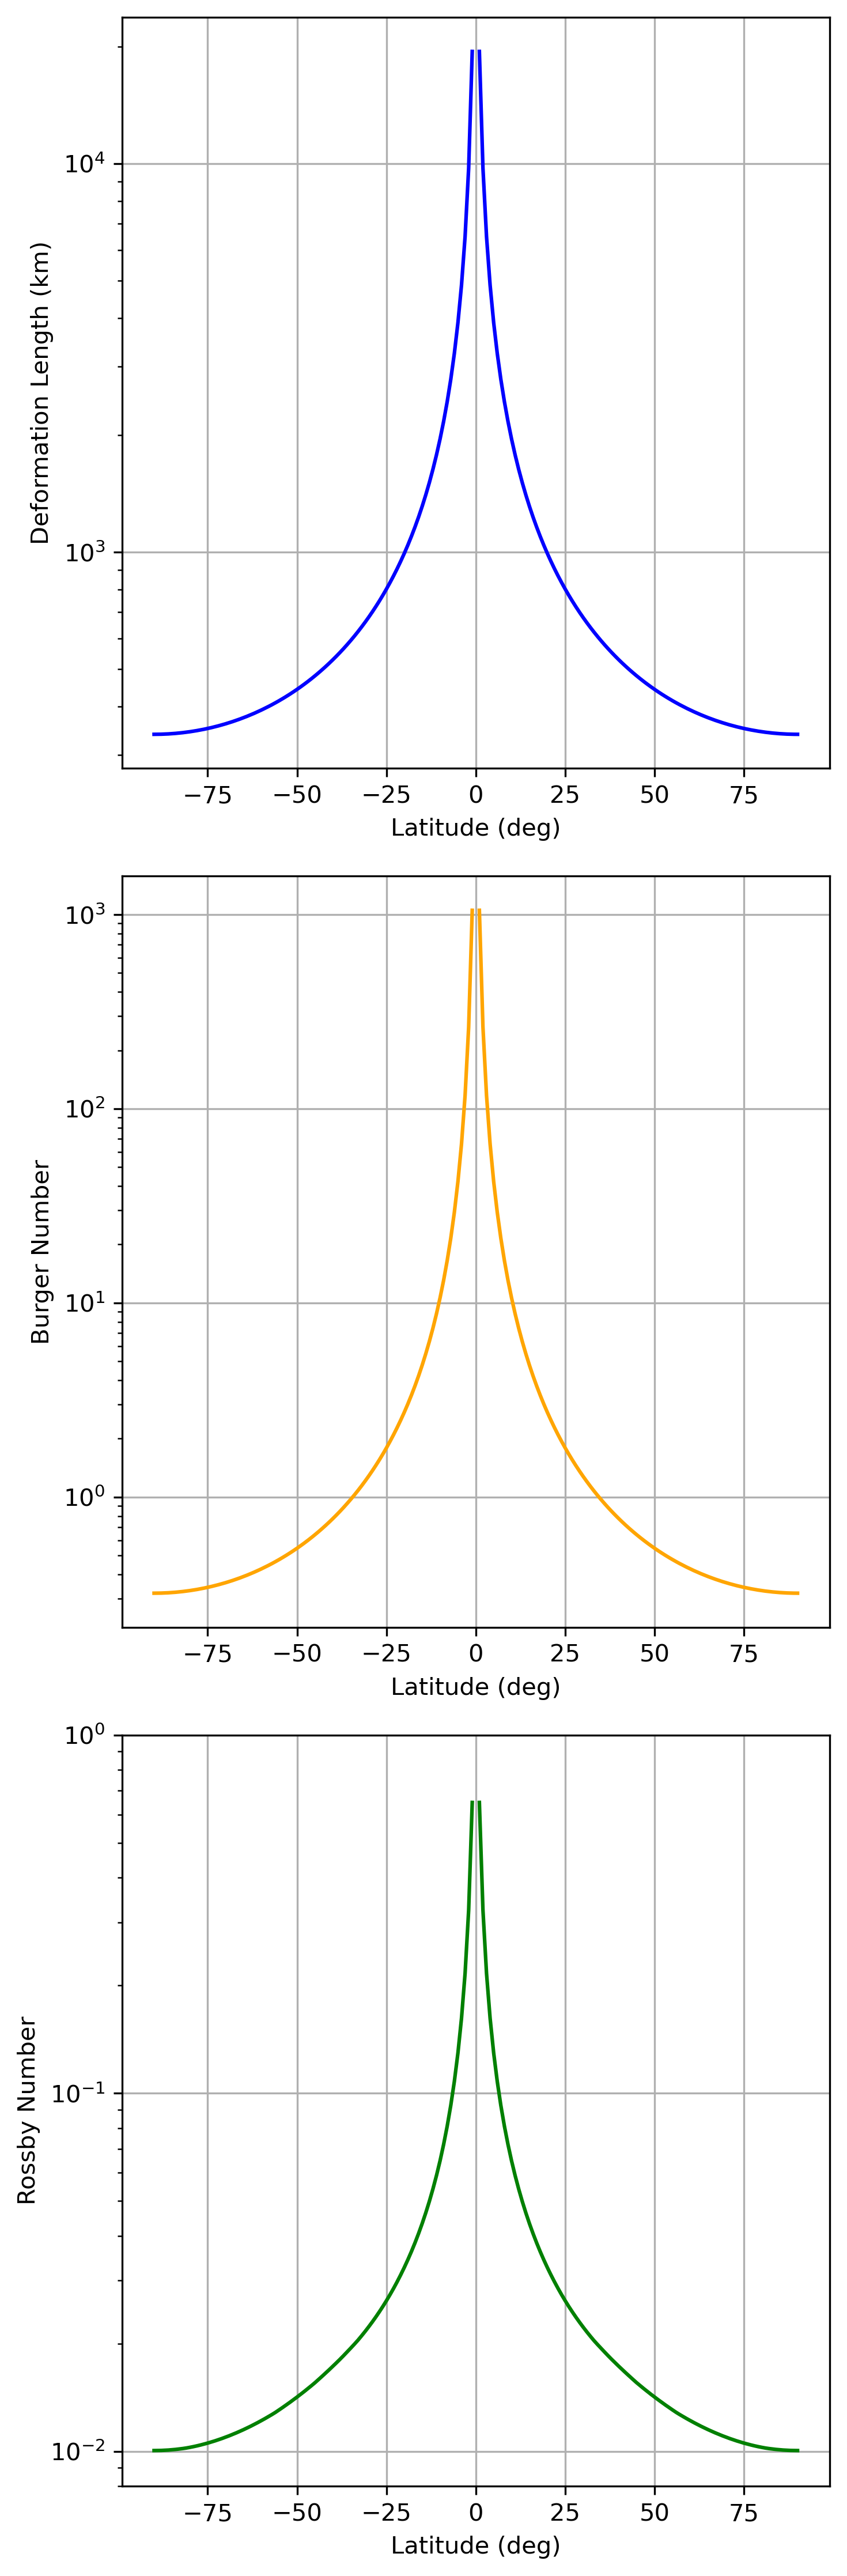

In [ ]:

fig, [ax1, ax2, ax3] = plt.subplots(3, 1, figsize=(5, 15), dpi=300)

ax1.plot(lats, L_d / 1000, color='blue')
ax1.set_yscale('log')
ax1.set_ylabel('Deformation Length (km)')
ax1.set_xlabel('Latitude (deg)')
ax1.grid()

ax2.plot(lats, B_u, color='orange') 
ax2.set_yscale('log')
ax2.set_ylabel('Burger Number')
ax2.set_xlabel('Latitude (deg)')
ax2.grid()

ax3.plot(lats, R_o, color='green')
ax3.set_yscale('log')
ax3.set_ylim(8*1e-3, 1e0)
ax3.set_ylabel('Rossby Number')
ax3.set_xlabel('Latitude (deg)')
ax3.grid()
plt.tight_layout()
plt.savefig('Lab_2_Outputs/Diagnostics.png', bbox_inches='tight')
plt.show()
plt.close()



## Interpretations

Address each of the following prompts in the markdown cell below them. In each response, be specific and reference your plots to support your points.

1. For a rotating experiment (i.e., $f_0 \ne 0$), describe the geostrophic adjustment process: explain what initiates motion, how the height and velocity fields subsequently evolve, and what evidence suggests that the central disturbance approaches geostrophic balance. Distinguish the central remnant from the outward-propagating waves.

At a point where f != 0 (aka farther away from the equator), the coreolis force has a strong affect on the behavior of the original pertibation. At the very beginning of the simulation (within the first 2 hours), all latitudes see a large burst in zonal wind away from the peak of the pertibation that is centered along the x = 0 axis. This makes intuitive sense, as the fluid is driven from rest into motion by the PGF present along both sides of the pertibation.   

Soon after the two hour mark though, geostrophic adjustment begins to occur. At latitudes where f is nonzero, coreolis force causes the flow to curve to the right at positive lats and left at negative lats. Wind direction primarily shifts from zonal to meridional flow, and the coreolis force becomes balanced with and opposes the direction of the pressure gradient force. This becomes geostrophic balance. The coreolis acceleation vector plot shows how this balance leads to the survival of the original pertibation.

2. Discuss the effects of changing $f_0$ and $L_0$ separately. What changes in the evolution and the remnant height anomaly at the center? Include the nonrotating case in your discussion. Incorporate $Ro$, $L_D$, and $Bu$ into your interpretations.

3. What's something surprising you learned or something you understand better now after this lab, either related to dynamics, modeling, or programming?